![Los Angeles County personel dropping water onto Palisades fire on January 7, 2025. Photo was accessed originally from CNN (https://www.cnn.com/2025/08/06/us/los-angeles-wildfires-440-excess-deaths-study), provided by DAVID SWANSON/AFP via Getty Images](/images/palisade_fire2.jpg)

## Background
The fire hazard conditions in Los Angeles County on January 7, 2025 were a coalescence of drought brought on by months without rainfall and Santa Ana winds that ripped through the dry brush in the Santa Monica mountains and Eaton Canyon. Fires in the Pacific Palisades and Eaton areas began to burn and spread quickly that morning due to the wind conditions, and several other fires burning strained fire response resources. The Los Angeles County Eaton and Palisades Fires After-Action Reviews highlighted that the county's issuance of evacuation warnings was complicated by fire conditions and the speed capability of public warnings systems. This emphasized issues with the timeliness of evacuation orders issued by the county. The fires resulted in 31 deaths total reported by the county, and affected more than 43,000 residents.


## Purpose of analysis
The scale of the Palisades and Eaton fires necessitated geospatial analysis to determine their effects. The goal of this post is to explore data pertaining to the Los Angeles County areas affected by the Palisades and Eaton Fires, and produce visualizations that aid in interpretting human and environmnental impact. These analyses were done in Python as work for EDS220 in the Bren MEDS program. [github: eds220-la-fires-eji](https://github.com/NatBonnet/eds220-la-fires-eji)

## Highlights of Analysis
- This analysis demonstrates use of the SpatioTemporal Asser Catalog (STAC). This catalog is an open access data archive with geospatial data available through various catalogs. We accessed the Microsoft Planetary Computer STAC API for items (GeoJSON features) that represented our spatial and temporal areas of interest. 
- data retrieved from the STAC API search were unpacked as `xarray`s and processed using methods from `rioxarray`. These features allow metadata inclusion in the data.
- The intersection between natural disasters and environmental injustice was explored by accessing socioeconomic data from the Environmental Justice Index and including it for visualization and interpretation purposes.

## Data sources

### Landsat 8 Satellite Data
Landsat remote sensing data is a useful tool for creating true and false color images, particularly as it relates to vegetation, which can be useful for visualizing burn area. We used a Landsat Collection 2 Level-2 atmosperically corrected surface reflectance dataset, collected by the Landsat 8 satellite. The data shows Los Angeles County on February 23, 2025. This imagery allows us to visualize the burned areas from the Palisades and Eaton fires. The data contain red, green, blue, NIR, and SWIR bands. Data was retrieved from the Microsoft Planetary Computer data catalogue and clipped to the area around Palisades/Eaton fire perimeters.

Planetary Computer. Microsoft Planetary Computer. https://planetarycomputer.microsoft.com/dataset/landsat-c2-l2


### California State Fire Perimeters Data
California has publicly accessible historical fire data available over a nearly 75 year period. The California Historical Fire Perimeters dataset was retrieved from the California State Geoportal Historical Wildland Fire Perimeters database. The data include many qualitative variables about fire impact, and importantly includes geographic data with fire id and specific date information.

California State Geoportal. California Historical Fire Perimeters [Dataset]. https://gis.data.ca.gov/datasets/CALFIRE-Forestry::california-historical-fire-perimeters/explore?layer=2&location=37.338129%2C-119.269051%2C6.09&showTable=true

### Environmental Justice Index (EJI) 2024
EJI provides nationwide data in the U.S. to represent environmental and health inequity issues. EJI's geodatabase was used in socioeconomic analysis as it relates to the impacts of the 2025 wilfires. 

Centers for Disease Control and Prevention, Agency for Toxic Substances and Disease Registry, Geospatial Research, Analysis, and Services Program (GRASP). 2024 EJI Technical Documentation. 


## Setup code and preliminary cleaning

In [20]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rio
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar

# Read in datasets
fp = os.path.join('data', 'landsat8-2025-02-23-palisades-eaton.nc')
landsat = xr.open_dataset(fp, engine='netcdf4')

fp = os.path.join('data', 'California_Historic_Fire_Perimeters_-247493000743518952', 'California_Fire_Perimeters_(1950+).shp')
fires = gpd.read_file(fp)

fp= os.path.join('data', 'EJI_2024_United_States', 'EJI_2024_United_States.gdb')
eji = gpd.read_file(fp)

# Clean up column names in fire data
fires.columns = fires.columns.str.lower()

# Check the CRS of the fires data
fires_crs = fires.crs

# Subset to individual fire perimeters for Palisades and Eatons
palisade_perimeter = fires[(fires['fire_name'] == 'PALISADES') & (fires['year_'] == 2025)]
eaton_perimeter = fires[(fires['fire_name'] == 'EATON') & (fires['year_'] == 2025)]

The python libraries needed to process the data described above were `numpy`, `pandas`, `geopandas`, `xarray`, `rioxarray`, `matplotlib`, `contextily`, and `ScaleBar` from `matplotlib_scalebar.scalebar` to produce the full final visualization. 

Fire data were filtered to contain only the Palisades and Eaton fires from 2025, and the column names were standardized. We needed to combine datasets in order to extract information from multiple at once, so in preliminary analysis it was important to know what the coordinate reference system (CRS) was of each dataset. The fire data had the  CRS EPSG:3857.

The Landsat data are stored in a NetCDF4 file. `.nc` files contain nested metadata and attributes that make processing less reliant on outside research and interpretation. This is an extremely useful format, but the processing steps look a bit different than for a `pd.Series` or `gpd.GeoDataFrame`. 

## Landsat data processing

In [2]:
# Find CRS of spatial reference in landsat data itself
crs = landsat.spatial_ref.crs_wkt

# Set the CRSof landsat equal to that of the spatial reference
landsat.rio.write_crs(crs, inplace= True)

<xarray.Dataset> Size: 78MB
Dimensions:      (y: 1418, x: 2742)
Coordinates:
  * y            (y) float64 11kB 3.799e+06 3.799e+06 ... 3.757e+06 3.757e+06
  * x            (x) float64 22kB 3.344e+05 3.344e+05 ... 4.166e+05 4.166e+05
    time         datetime64[ns] 8B ...
    spatial_ref  int64 8B 0
Data variables:
    red          (y, x) float32 16MB ...
    green        (y, x) float32 16MB ...
    blue         (y, x) float32 16MB ...
    nir08        (y, x) float32 16MB ...
    swir22       (y, x) float32 16MB ...

Our above output displays that the `landsat` NetCDF contains dimensions, variables, indexes, attributes. 

Because of the way NetCDFs are structured, there is not a CRS explicitly contained by the `.nc` itself. If you run `landsat.rio.crs` to check the CRS of the dataset, it will return 'None'. This must be pulled out of the spatial reference of the data itself. The CRS is then assigned to the `landsat` data object.

## Using Landsat data to create a true color image

A true color image uses red, green, and blue color bands in their respective order to visualize reflectance data as an image. 

Here we were interested in visualizing the burned areas from the Los Angeles County fires soon after they had been contained and could be seen on satellite imagery. 

We achieve this by calling color bands from landsat into place and plotting the data as a `numpy` array as an image on a 2D raster. Doing this with the same code shown in the image below results in two warning messages.

![Warnings from initial plotting attempt](/images/preliminary_true_color_errors.png)

There are two issues being indicated here. The first issue points to the reflectance data exceeding the valid range. This occurs often due to cloud cover compressing data due to high reflectance data being included. We address this by adding the argument `robust = True` to our plot. This parameter explicitly provides the colormap range with the 2nd and 98th percentiles rather than the most extreme values contained. 

The second issue is a bit less clear, but addresses that some data is invalid. This suggests there may be NA values contained in our array. We can easily replace NA values with 0 so they are displayed with the 0 reflectance data. 

These fixes will render the plot without error, producing a true color image of Los Angeles county. In this image we see large swaths of brown discoloration which are the fire scars from the Palisades and Eaton fires. We subsequently used a different technique to visualize this difference in vegetation more clearly.

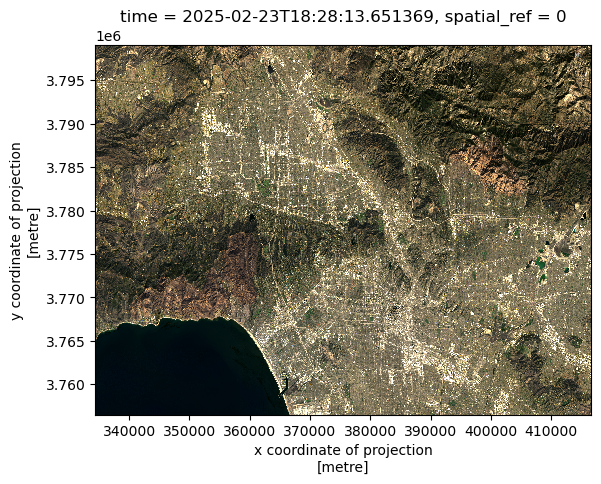

In [3]:
# Fill missing values in landsat data
landsat = landsat.fillna(0)

# Rerender plot without warnings
plt.show(landsat[["red", "green", "blue"]].to_array().plot.imshow(robust = True))

## Using a false color image to visualize fire scars
We can reorder bands and use infared reflectance in order to create a false color image. This can be helpful for visualizing various environmental processes or natural events that is difficult to see as they appear as a camera image. 

Using the short wave infared (SWIR) reflectance band in place of red, near infared (NIR) instead of green, and red instead of blue is a common false color composite for visualizing fire damage. Newly burned areas strongly reflect SWIR as bare soil is exposed in contrast to vegetation. 

We were interested in combining recorded fire perimeter data to confirm the extent of both fires visible from the Landsat data. 

To use both datasets together, we needed to match the CRS of the data. As seen with the initial processing for `landsat`, we can access the CRS with `landsat.rio.crs` now, and set the CRS of the Palisades and Eaton perimeter dataframes to be the same. 

We can plot SWIR, NIR, and red bands as a false color image by extracting the names of the bands as contained by 'data variables' in the landsat data. 

The boundary of the perimeter data is plotted onto the false color image using `boundary.plot()` in `matplotlib`. 
To create a cleaner looking map, I opted to remove axis ticks and labels in favor of a scalebar and compass arrow. To access the scalebar, I accessed the package 'ScaleBar' from `matplotlib_scalebar.scalebar`. With this function, the resolution, units, and location of the scalebar on the map can be specified. The Landsat data contains image resolution of 1 meter, so we use those parameters here.

The `ax.annotate` function can be used to initialize and add a compass arrow to a specified location on the map. 

Similarly, fire location labels were added using `fig.text` options to specify labels and their positions. 

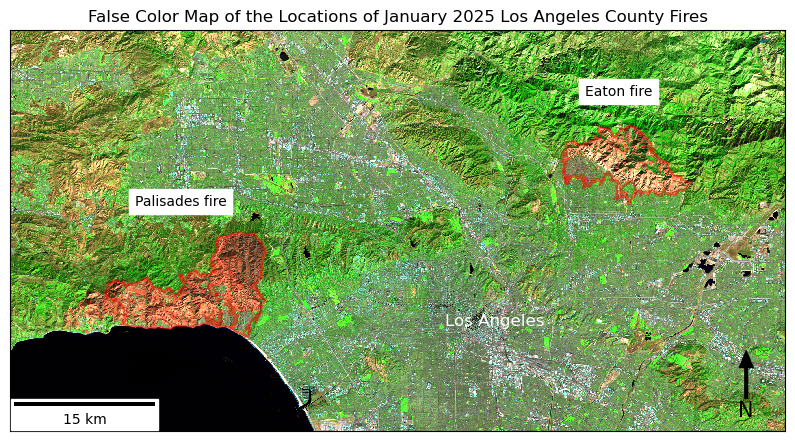

In [4]:
# Change CRS of fires data to match that of landsat data
palisade_perimeter = palisade_perimeter.to_crs(crs = landsat.rio.crs)
eaton_perimeter = eaton_perimeter.to_crs(crs = landsat.rio.crs)

# Initialize plot
fig, ax = plt.subplots(figsize = (10, 10))

# Underlay landsat false color image plot
landsat[["swir22", "nir08", "red"]].to_array().plot.imshow(ax=ax, 
                                                           robust = True)

# Add Palisade fire area onto plot
palisade_perimeter.boundary.plot(ax=ax, color = 'red', alpha = 0.5)

# Add Eaton fire area onto plot
eaton_perimeter.boundary.plot(ax=ax, color = "red", alpha = 0.5)

# Add informative title
plt.title("False Color Map of the Locations of January 2025 Los Angeles County Fires")

# Add a scalebar with matplotlib ScaleBar function
scalebar = ScaleBar(dx = 1, # Specify resolution of cell being measured
                     units = 'm', # Cells are 1m res
                     location = "lower left") # Add to lower left of plot
ax.add_artist(scalebar)

# Add compass arrow by initializing area on plot and size
x, y, arrow_length = 0.95, 0.2, 0.15

# Add annotation with text and arrow/text
ax.annotate('N', xy=(x, y), xytext=(x, y-arrow_length),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            ha='center', va='center', fontsize=15,
            xycoords=ax.transAxes)

# Add Palisade fire annotation
fig.text(x = 0.25, 
         y = 0.52, 
         s = "Palisades fire", 
         backgroundcolor = 'white')

# Add Eaton fire annotation
fig.text(x = 0.7, 
         y = 0.63, 
         s = "Eaton fire", 
         backgroundcolor = 'white')

# Add label to downtown Los Angeles for visual context
fig.text(x = 0.56, 
         y = 0.4, 
         s = "Los Angeles", 
         color = 'white', 
         fontsize = 'large')

# Remove axes ticks
ax.set_xticks([])  
ax.set_yticks([])  

# Remove axes labels
ax.set_xlabel("")  
ax.set_ylabel("")  

plt.show()

## Socioeconomic impacts
Based on the map highlighting burned areas, it is apparent that the Palisades and Eaton fires had a large scale impact on LA County residents. To highlight challenges and possible environmental injustices as a result of the fires, EJI data was used to identify disparities between residents in Pacific Palisades and Eaton Canyon. 

To combine fire perimeter data with EJI data, the CRS of EJI was transformed to match the perimeter datasets. A spatial join for both fires was performed using the default inner join on a `geopandas.geoDataFrame`. 

From there, the extent of the joined data frame was clipped to the exact perimeter of the fires so that only EJI variables within the fire area were being visualized. 

In [5]:
eji = eji.to_crs(crs = palisade_perimeter.crs)

# Spatial join
palisade_soc = gpd.sjoin(left_df = eji, 
                        right_df = palisade_perimeter,
how = 'inner')

# Create geodf for the Eaton fire
# Spatial join
eaton_soc = gpd.sjoin(eji, eaton_perimeter,
how = 'inner')

# Clip the census tracts overlapping palisades to the boundary of the fire
palisade_clip = gpd.clip(eji, palisade_perimeter)

eaton_clip = gpd.clip(eji, eaton_perimeter)

## Verify clipped data matches known fire perimeters
The false color image from Landsat imagery showed real time fire scar area that was verified by the reported fire perimeters. We can check that the EJI joined nd clipped data matches the same extent, and position the fires on a given basemap to see the fires in relation to map components like you might see on Google Maps. 

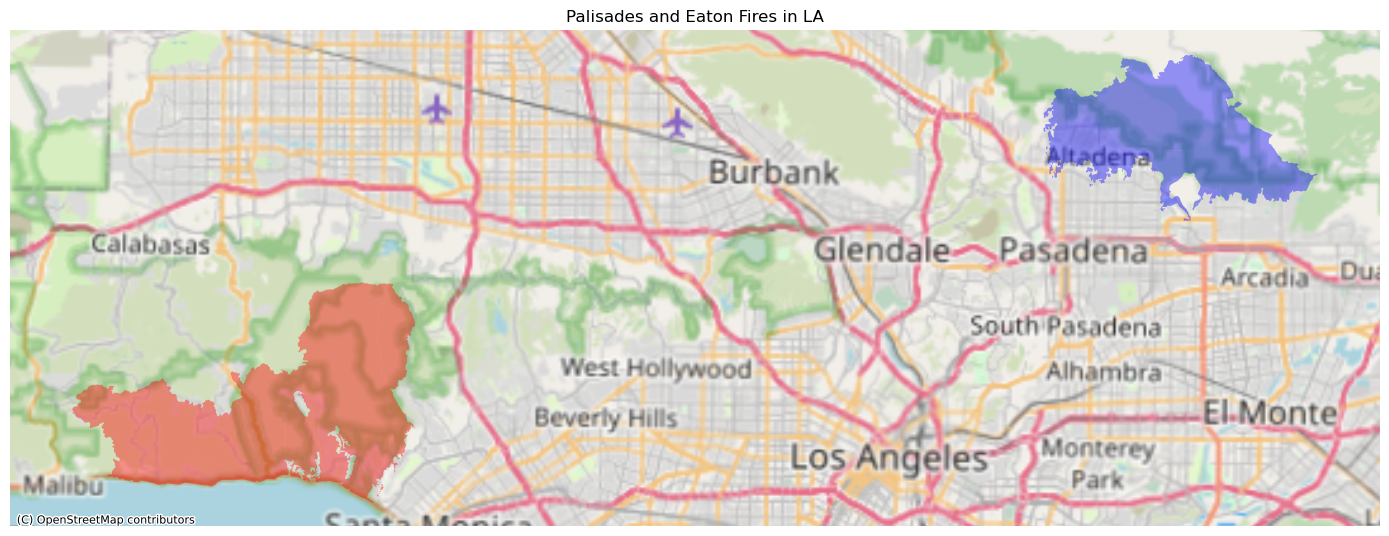

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

palisade_clip.plot(ax=ax, color = "red", alpha = 0.4)

eaton_clip.plot(ax=ax, color = "blue", alpha = 0.4)
# Add basemap using contextily
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs = palisade_clip.crs)

ax.set_title("Palisades and Eaton Fires in LA")

ax.axis('off')

plt.tight_layout()
plt.show()

To render the basemap, the contextily library containing open source basemaps was used. 'OpenStreetMap.Mapnik` was the specified package used. Here it is again necessary to set the CRS to be the same as the clipped data.

## Visualizing the percent of residents living in poverty impacted
Several variables contained by EJI 2024 data could be investigated as factors that might impede fire recovery, or have contributed to a worse social impact in certain communities. The variable I chose to visualize from EJI was the percentage of residents living under the poverty line in the burned areas. This seemed like an obvious barrier to rebuilding property and possessions. 

To plot the clipped Palisade and Eaton fire perimeter data by the EJI variable of interest, the column was called from the clipped perimeter data including EJI information. The name of the variable of interest was accessible via the EJI metadata. Percent living in poverty was specified by the 'E_POV200' column. The name of the variable to search by was stored as an object to use in plotting.

In order to coerce the visual output so that both area plots have the same color bar, the minimum and maximum values of percent in poverty were defined for each area, and the absolute minimum and maximum values from the two were used to set the color bar range in plotting. 

In [ ]:
# Define EJI variable of choice to fill corresponding area values with
eji_variable = 'E_POV200'

# Find the minimum and maxium for the overall legend so all values are shared across plots
vmin = min(palisade_clip[eji_variable].min(), eaton_clip[eji_variable].min())
vmax = max(palisade_clip[eji_variable].max(), eaton_clip[eji_variable].max())

The plots for the clipped and joined data from each fire were plotted together on the same axis with the overall minimum and maximum values previously defined to make sure that colors would correspond to the same values on each map. Then a custom color bar was created in a new axis for both plots using the scale defined before. 

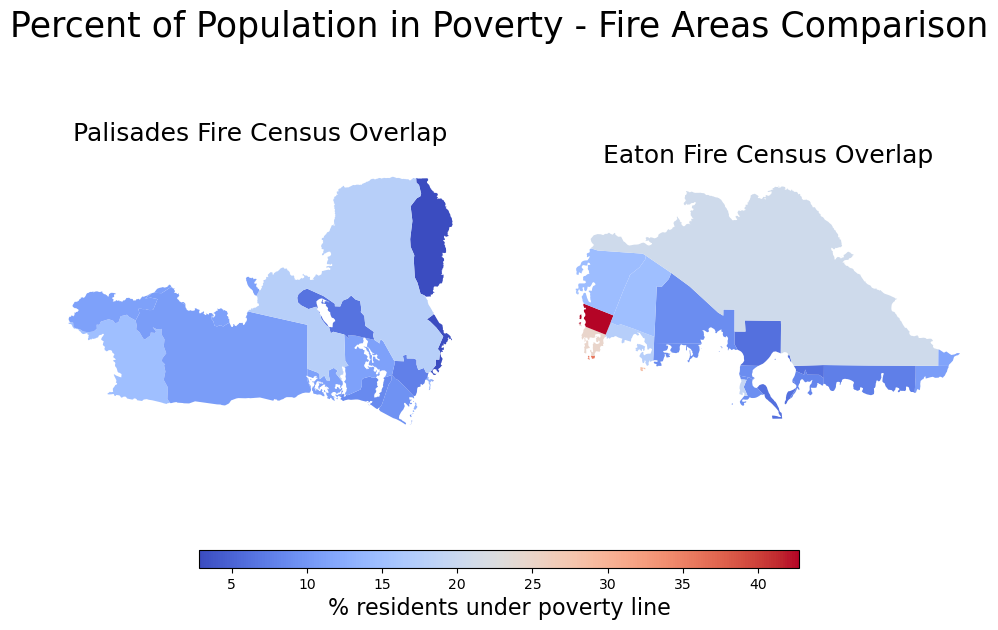

In [19]:
# Initialize plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot census tracts within Palisades perimeter
palisade_clip.plot(
    column= eji_variable,
    cmap = 'coolwarm',
    vmin=vmin, vmax=vmax,
    legend=False,
    ax=ax1)

# Add unique title for Palisades plot
ax1.set_title('Palisades Fire Census Overlap', fontsize = 18)
ax1.axis('off')

# Plot census tracts within Eaton perimeter
eaton_clip.plot(
    column=eji_variable,
    cmap = 'coolwarm',
    vmin=vmin, vmax=vmax,
    legend=False,
    ax=ax2)

# Add unqiue title for Eaton plot
ax2.set_title('Eaton Fire Census Overlap', fontsize = 18)
ax2.axis('off')

# Add overall title
fig.suptitle('Percent of Population in Poverty - Fire Areas Comparison', fontsize = 25)

# Add shared colorbar at the bottom
sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap = 'coolwarm')
# [left, bottom, width, height]
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.03]) 
# Set the position of the custom color bar
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal') 
# Label the color bar itself
cbar.set_label('% residents under poverty line', fontsize = 16)

plt.show()

## Interpretation and discussion
Through the above workflow, I visualized the impacts of the Palisades and Eaton fires by creating at fire scar Landsat imagery, comparing to recorded historical fire perimeter data, and integrating a socioeconomic impact of choice. 

The comparison of residents living in poverty between Pacific Palisades and Eaton Canyon elucides a general pattern of greater mean poverty rates in the Eaton area, visible by the larger areas of lighter colored census tracts. I predicted that this might have resulted in longer time to recover from the fire in poorer areas, potentially a greater need for social services, and likely disparities in how communities were treated after the fact. 

Out of interest, I explored a National Institutes of Health article which conducted a study using the 2022 Center for Disease Control and Prevention's Social Vulnerability Index to quantify differential impacts.

This confirmed what is demonstrated above, that Eaton residents were more likely to be low-income. The analysis also suggested that Palisades residents were more likely to have owned vacant second homes in the area, and more people working from home (potentially better able to evacuate quickly). 

Their conclusions were that the Eaton fire affected more socially vulnerable communities with greater challenges at every stage of the fire and recovery, including evacuation and need for assistance. Analysis of employment data suggested that Eaton residents experienced a larger housing cost burden, and displacement from the fire increased vulnerability to predatory renter policies and the dismantling of social cohesion during the time.

## References
After-action review of alert notification systems ... - lacounty. https://file.lacounty.gov/SDSInter/bos/supdocs/207915.pdf 

County of Los Angeles. (2025, September 25). LA County Releases After-Action Review of Alert Notification Systems and Evacuation Policies for the Eaton and Palisades Fires. COUNTY OF LOS ANGELES. https://lacounty.gov/2025/09/25/la-county-releases-after-action-review-of-alert-notification-systems-and-evacuation-policies-for-the-eaton-and-palisades-fires/ 

Sentinel-Hub by Sinergise. Simple RGB composites (sentinel-2). Sentinel Hub custom scripts. https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/composites/ 

Wong, M. S., Steers, W. N., & Washington, D. L. (2025, July 23). Inequities in weathering California wildfires. Health affairs scholar. https://pmc.ncbi.nlm.nih.gov/articles/PMC12397747/ 

Xarray.plot.imshow. xarray. (2025, November 28). https://docs.xarray.dev/en/stable/generated/xarray.plot.imshow.html 